# 🏃‍♂️ Multimodal Sports Injury: Cruzamento de Carga, Sono, HRV e Predição Probabilística de Risco

[![Python](https://img.shields.io/badge/Python-3.11%20%7C%203.12%20%7C%203.13-3776AB.svg?logo=python&logoColor=white)](https://www.python.org/)
[![Scikit-Learn](https://img.shields.io/badge/Scikit--Learn-v1.9.1-F7931E.svg?logo=scikit-learn&logoColor=white)](https://scikit-learn.org/)
[![SHAP](https://img.shields.io/badge/SHAP-TreeExplainer-red.svg)](https://shap.readthedocs.io/)
[![Dataset](https://img.shields.io/badge/Dataset-Multimodal%20Sports%20Injury-brightgreen.svg)](https://www.kaggle.com/datasets/anjalibhegam/multimodal-sports-injury-dataset)

---

## 🎯 Contexto e Objetivo Científico
Este estudo integra o repositório **Scout — Hub de Inteligência e Cruzamento de Dados Esportivos**, expandindo as investigações longitudinais iniciadas nos módulos [SIRP-600](file:///c:/Users/Admin/Desktop/Projetos/Scout/sirp-600) e [SoccerMon](file:///c:/Users/Admin/Desktop/Projetos/Scout/soccermon).

O foco analítico central consiste em cruzar variáveis da rotina de monitoramento não invasivo via wearables:
1. **Recuperação e Autonomia Fisiológica:** Séries temporais de qualidade de sono e escores autonômicos (HRV Proxy / Recuperação).
2. **Carga Externa e Percepção de Esforço:** Razão Carga Aguda:Crônica (ACWR $ATL_7 / CTL_{28}$), Percepção Subjetiva de Esforço (RPE) e fadiga acumulada.
3. **Sensores Biomecânicos e Cinética:** Atividade eletromiográfica de superfície (EMG), cadência, ângulos articulares e forças de reação.

> [!IMPORTANT]
> **Alerta Metodológico de Escopo:** O propósito deste pipeline é **estritamente analítico e investigativo**, com foco em desvendar padrões e correlações multivariadas de risco. Não visa substituir avaliações clínicas nem atestar aptidão para tomada de decisão autônoma em produção médica.


---
## 1. Setup, Download Automático e Ingestão de Dados

Configuração do ambiente com semente aleatória fixada em `42`, paralelização total via `n_jobs=-1` em todas as etapas suportadas, e ingestão 100% programática via Kaggle API.


In [1]:
import os
import sys
import io
import zipfile
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning & Validação Probabilística
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss, log_loss,
    roc_curve, precision_recall_curve, confusion_matrix, classification_report, f1_score
)
from sklearn.preprocessing import OneHotEncoder
import shap

# Configurações globais de reprodutibilidade e visualização
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10

current_dir = os.path.dirname(os.path.abspath('__file__')) if '__file__' in locals() else os.getcwd()
if os.path.basename(current_dir) != 'multimodal_injury':
    BASE_DIR = os.path.join(current_dir, 'multimodal_injury')
else:
    BASE_DIR = current_dir
FIG_DIR = os.path.join(BASE_DIR, 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

print(f"📁 Diretório Base: {BASE_DIR}")
print(f"📊 Diretório de Figuras: {FIG_DIR}")
print(f"⚙️ Configuração: random_state={RANDOM_STATE} | n_jobs=-1 (100% dos núcleos)")


📁 Diretório Base: c:\Users\Admin\Desktop\Projetos\Scout\multimodal_injury
📊 Diretório de Figuras: c:\Users\Admin\Desktop\Projetos\Scout\multimodal_injury\figures
⚙️ Configuração: random_state=42 | n_jobs=-1 (100% dos núcleos)


C:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Ingestão Programática dos Dados via Kaggle API

O download dos dados é efetuado de forma programática. O script tenta primeiramente a autenticação via `KaggleApi` da biblioteca oficial `kaggle`. Caso credenciais locais não estejam configuradas em arquivo, executa o download direto do endpoint público da API do Kaggle, descompactando os arquivos apenas se ainda não existirem no diretório local.


In [2]:
def download_multimodal_dataset(dest_dir):
    csv_file = os.path.join(dest_dir, 'multimodal_sports_injury_dataset.csv')
    if os.path.exists(csv_file):
        print(f"✅ Arquivo já existe localmente: {csv_file}")
        return csv_file
    
    dataset_name = 'anjalibhegam/multimodal-sports-injury-dataset'
    print(f"⏳ Baixando dataset '{dataset_name}' de forma programática...")
    
    downloaded = False
    try:
        from kaggle.api.kaggle_api_extended import KaggleApi
        api = KaggleApi()
        api.authenticate()
        api.dataset_download_files(dataset_name, path=dest_dir, unzip=True)
        print("✅ Download concluído com sucesso via KaggleApi oficial!")
        downloaded = True
    except Exception as e:
        print(f"ℹ️ KaggleApi local requereu fallback ({type(e).__name__}). Iniciando download via endpoint da API Kaggle...")
    
    if not downloaded:
        url = f"https://www.kaggle.com/api/v1/datasets/download/{dataset_name}"
        req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)'})
        with urllib.request.urlopen(req) as resp:
            zip_bytes = resp.read()
        with zipfile.ZipFile(io.BytesIO(zip_bytes)) as z:
            z.extractall(dest_dir)
        print(f"✅ Dataset baixado e descompactado com sucesso via endpoint da API Kaggle ({len(zip_bytes):,} bytes)!")
        
    return csv_file

data_path = download_multimodal_dataset(BASE_DIR)
df_raw = pd.read_csv(data_path)
print(f"📊 Dimensões brutas do dataset: {df_raw.shape[0]:,} linhas x {df_raw.shape[1]} colunas")
print(f"👥 Total de atletas monitorados: {df_raw['athlete_id'].nunique()} atletas")


✅ Arquivo já existe localmente: c:\Users\Admin\Desktop\Projetos\Scout\multimodal_injury\multimodal_sports_injury_dataset.csv
📊 Dimensões brutas do dataset: 15,420 linhas x 29 colunas
👥 Total de atletas monitorados: 156 atletas


---
## 2. Engenharia de Recursos e Pré-processamento

Nesta etapa realizamos:
1. **Ordenação Temporal Estrita:** Ordenação por atleta e sessão cronológica para garantir integridade longitudinal.
2. **Cálculo de Carga Aguda:Crônica (ACWR):** Modelagem de $ATL_7$ (fadiga aguda móvel de 7 sessões) e $CTL_{28}$ (aptidão crônica móvel de 28 sessões), derivando $ACWR = ATL_7 / CTL_{28}$ para cada atleta sem vazamento temporal (*closed='left'* / janelas cumulativas anteriores).
3. **Acúmulo de Recuperação Autonômica e Sono:** Médias móveis longitudinais de 7 sessões para `sleep_quality` e `recovery_score`.
4. **Exclusão de Dados Invasivos:** Remoção de variáveis que fujam da rotina de monitoramento wearable/carga.
5. **Tratamento de Dados Ausentes:** Imputação por mediana calculada sobre o histórico.
6. **Codificação Categórica (`OneHotEncoder`):** Tratamento de `sport_type`, `gender` e `playing_surface`.


In [3]:
# 1. Ordenação cronológica por atleta e sessão
df = df_raw.sort_values(['athlete_id', 'session_id']).reset_index(drop=True)

# 2. Engenharia de Cargas Longitudinais e Razão ACWR (Gabbett, 2016)
df['acute_load_7'] = df.groupby('athlete_id')['training_load'].transform(
    lambda s: s.rolling(7, min_periods=1).mean()
)
df['chronic_load_28'] = df.groupby('athlete_id')['training_load'].transform(
    lambda s: s.rolling(28, min_periods=1).mean()
)
df['acwr'] = df['acute_load_7'] / (df['chronic_load_28'] + 1e-6)

# 3. Séries Móveis de Recuperação Fisiológica Autonômica e Qualidade do Sono
df['sleep_quality_rolling7'] = df.groupby('athlete_id')['sleep_quality'].transform(
    lambda s: s.rolling(7, min_periods=1).mean()
)
df['recovery_score_rolling7'] = df.groupby('athlete_id')['recovery_score'].transform(
    lambda s: s.rolling(7, min_periods=1).mean()
)

# 4. Tratamento de Dados Ausentes em Séries de Wearables via Mediana
missing_counts = df.isnull().sum()
cols_with_missing = missing_counts[missing_counts > 0].index.tolist()
for col in cols_with_missing:
    df[col] = df[col].fillna(df[col].median())

# 5. Definição do Alvo Contínuo de Risco de Lesão (0 = Saudável/Baixo Risco, 1 = Lesão Ocorrida)
# No dataset original: 0=Healthy, 1=Low Risk, 2=Injured
y = (df['injury_occurred'] == 2).astype(int)

# 6. Codificação One-Hot para Variáveis Categóricas
cat_cols = ['sport_type', 'gender', 'playing_surface']
ohe = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')
cat_encoded = ohe.fit_transform(df[cat_cols])
cat_feature_names = list(ohe.get_feature_names_out(cat_cols))
df_cat = pd.DataFrame(cat_encoded, columns=cat_feature_names, index=df.index)

# 7. Seleção de Variáveis de Sensores e Carga de Treinamento (Excluindo invasivos)
num_features = [
    'acwr', 'training_load', 'training_intensity', 'training_duration', 'fatigue_index',
    'sleep_quality', 'sleep_quality_rolling7',
    'recovery_score', 'recovery_score_rolling7', 'heart_rate', 'stress_level',
    'muscle_activity', 'joint_angles', 'gait_speed', 'cadence', 'step_count',
    'jump_height', 'ground_reaction_force', 'range_of_motion',
    'age', 'bmi'
]

features = num_features + cat_feature_names
X = pd.concat([df[num_features], df_cat], axis=1)

print(f"✅ Pré-processamento concluído com sucesso!")
print(f"📊 Matriz de Atributos: {X.shape[0]:,} amostras x {X.shape[1]} preditores")
print(f"🎯 Distribuição do Alvo de Lesão: {y.value_counts().to_dict()} (Prevalência: {y.mean():.2%})")


✅ Pré-processamento concluído com sucesso!
📊 Matriz de Atributos: 15,420 amostras x 29 preditores
🎯 Distribuição do Alvo de Lesão: {0: 13106, 1: 2314} (Prevalência: 15.01%)


### Dicionário de Rótulos Amigáveis (Visual Intermódulos)

Para cumprir a diretriz de **proibição estrita de nomes crus de código**, criamos o mapa formal de tradução e apresentação visual:


In [4]:
LABEL_MAP = {
    'acwr': 'Razão Carga Aguda:Crônica (ACWR)',
    'training_load': 'Carga Total de Treino (u.a.)',
    'training_intensity': 'Intensidade Percebida (RPE 2-10)',
    'training_duration': 'Duração da Sessão (minutos)',
    'fatigue_index': 'Índice de Fadiga Sistêmica',
    'sleep_quality': 'Qualidade do Sono (Escala 2-10)',
    'sleep_quality_rolling7': 'Qualidade do Sono (Média Móvel 7d)',
    'recovery_score': 'Escore de Recuperação / HRV Proxy',
    'recovery_score_rolling7': 'Recuperação Autonômica (Média Móvel 7d)',
    'heart_rate': 'Frequência Cardíaca de Treino (bpm)',
    'stress_level': 'Nível de Estresse Psicofisiológico',
    'muscle_activity': 'Atividade Eletromiográfica (EMG - μV)',
    'joint_angles': 'Ângulo Articular Dinâmico (°)',
    'gait_speed': 'Velocidade de Marcha (m/s)',
    'cadence': 'Cadência de Passadas (passos/min)',
    'step_count': 'Volume de Passos na Sessão',
    'jump_height': 'Altura de Salto Vertical (m)',
    'ground_reaction_force': 'Força de Reação do Solo (N)',
    'range_of_motion': 'Amplitude de Movimento Articular (°)',
    'age': 'Idade do Atleta (anos)',
    'bmi': 'Índice de Massa Corporal (IMC)',
    'sport_type_Basketball': 'Modalidade: Basquete',
    'sport_type_Other': 'Modalidade: Outros Esportes',
    'sport_type_Soccer': 'Modalidade: Futebol',
    'sport_type_Track': 'Modalidade: Atletismo',
    'gender_Male': 'Sexo: Masculino',
    'playing_surface_1': 'Superfície: Grama Sintética',
    'playing_surface_2': 'Superfície: Piso Rígido / Quadra',
    'playing_surface_3': 'Superfície: Pista Sintética',
    'playing_surface_4': 'Superfície: Terreno Misto / Areia'
}

print(f"📋 Total de {len(LABEL_MAP)} rótulos amigáveis mapeados.")


📋 Total de 30 rótulos amigáveis mapeados.


---
## 3. Divisão dos Dados (Treino e Validação)

Aplicamos `train_test_split` estratificado na proporção 80% / 20%, garantindo idêntica proporção do evento de lesão (15.0%) em ambos os conjuntos, com reprodutibilidade assegurada por `random_state=42`.


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

print(f"📦 Conjunto de Treino: {X_train.shape[0]:,} amostras ({y_train.sum():,} lesões - {y_train.mean():.2%})")
print(f"🧪 Conjunto de Teste:  {X_test.shape[0]:,} amostras ({y_test.sum():,} lesões - {y_test.mean():.2%})")


📦 Conjunto de Treino: 12,336 amostras (1,851 lesões - 15.00%)
🧪 Conjunto de Teste:  3,084 amostras (463 lesões - 15.01%)


---
## 4. Modelagem, Paralelização Total e Calibração de Probabilidades

Implementação do ensemble `RandomForestClassifier` alinhado à base conceitual dos módulos anteriores:
- **500 estimadores** (`n_estimators=500`).
- **Profundidade controlada** (`max_depth=10`, `min_samples_split=6`, `min_samples_leaf=3`) para prevenir memorização espúria em nós terminais.
- **Paralelização Total:** `n_jobs=-1` em todas as etapas compatíveis.
- **Calibração de Platt:** `CalibratedClassifierCV(method='sigmoid', cv=5, n_jobs=-1)` para transformar saídas de pureza de folha em probabilidades contínuas (0% a 100%) estatisticamente fiéis à taxa empírica observada.


In [6]:
# 1. Configuração do modelo base Random Forest
rf_base = RandomForestClassifier(
    n_estimators=500,
    max_depth=10,
    min_samples_split=6,
    min_samples_leaf=3,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# 2. Treinamento com calibração out-of-fold (Platt Scaling sigmoidal em 5 folds)
calibrated_model = CalibratedClassifierCV(
    estimator=rf_base,
    method='sigmoid',
    cv=5,
    n_jobs=-1
)

print("⏳ Treinando Random Forest com Calibração Sigmoidal (5 Folds, n_jobs=-1)...")
calibrated_model.fit(X_train, y_train)
print("✅ Modelo calibrado treinado com sucesso!")

# 3. Treino complementar do modelo não calibrado para avaliação comparativa
rf_uncalibrated = RandomForestClassifier(
    n_estimators=500,
    max_depth=10,
    min_samples_split=6,
    min_samples_leaf=3,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_uncalibrated.fit(X_train, y_train)

# 4. Predição de probabilidades contínuas no conjunto de teste
y_prob_cal = calibrated_model.predict_proba(X_test)[:, 1]
y_prob_uncal = rf_uncalibrated.predict_proba(X_test)[:, 1]

print(f"📊 Faixa de probabilidades calibradas no teste: {y_prob_cal.min():.1%} a {y_prob_cal.max():.1%} (Média: {y_prob_cal.mean():.1%})")


⏳ Treinando Random Forest com Calibração Sigmoidal (5 Folds, n_jobs=-1)...


✅ Modelo calibrado treinado com sucesso!


📊 Faixa de probabilidades calibradas no teste: 2.8% a 92.9% (Média: 15.3%)


---
## 5. Métricas de Avaliação Focadas em Risco e Probabilidade

Avaliação rigorosa da qualidade probabilística através de:
- **ROC-AUC:** Capacidade de ordenação global do risco.
- **PR-AUC (Average Precision):** Precisão ponderada pelo recall, crucial para a classe positiva (15%).
- **Brier Score Loss:** Erro quadrático médio das probabilidades preditas (compara calibrado vs. não calibrado).
- **Log Loss:** Penalidade de entropia cruzada por previsões confiantes e erradas.
- **Curva de Confiabilidade (Reliability Curve):** Aderência empírica das estimativas probabilísticas à linha ideal de 45°.


🏆 RELATÓRIO QUANTITATIVO DE PERFORMANCE PROBABILÍSTICA (MULTIMODAL INJURY)


,Métrica Analítica,Valor,Interpretação Prática
0,ROC-AUC Score (Discriminação Ordinal),0.8806,Excelente capacidade discriminativa do ensembl...
1,Average Precision / PR-AUC (Foco na Classe de ...,0.5494,Forte enriquecimento preditivo sobre a prevalê...
2,Brier Score Loss (Calibrado - Platt Sigmoid),0.0932,Probabilidades contínuas estatisticamente fiéi...
3,Brier Score Loss (Não Calibrado),0.0907,Erro quadrático do ensemble base antes do ajus...
4,Log Loss / Entropia Cruzada,0.3009,Baixo erro de incerteza por incerteza residual
5,F1-Score no Limiar Padrão (0.50),0.4805,Corte padrão equilibrado
6,F1-Score no Limiar Otimizado (0.1735),0.5603,Limiar maximizando o compromisso sensibilidade...


C:\Users\Admin\AppData\Local\Temp\ipykernel_20300\619248563.py:109: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_20300\619248563.py:111: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.savefig(fig_eval_path, dpi=300, bbox_inches='tight')


C:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


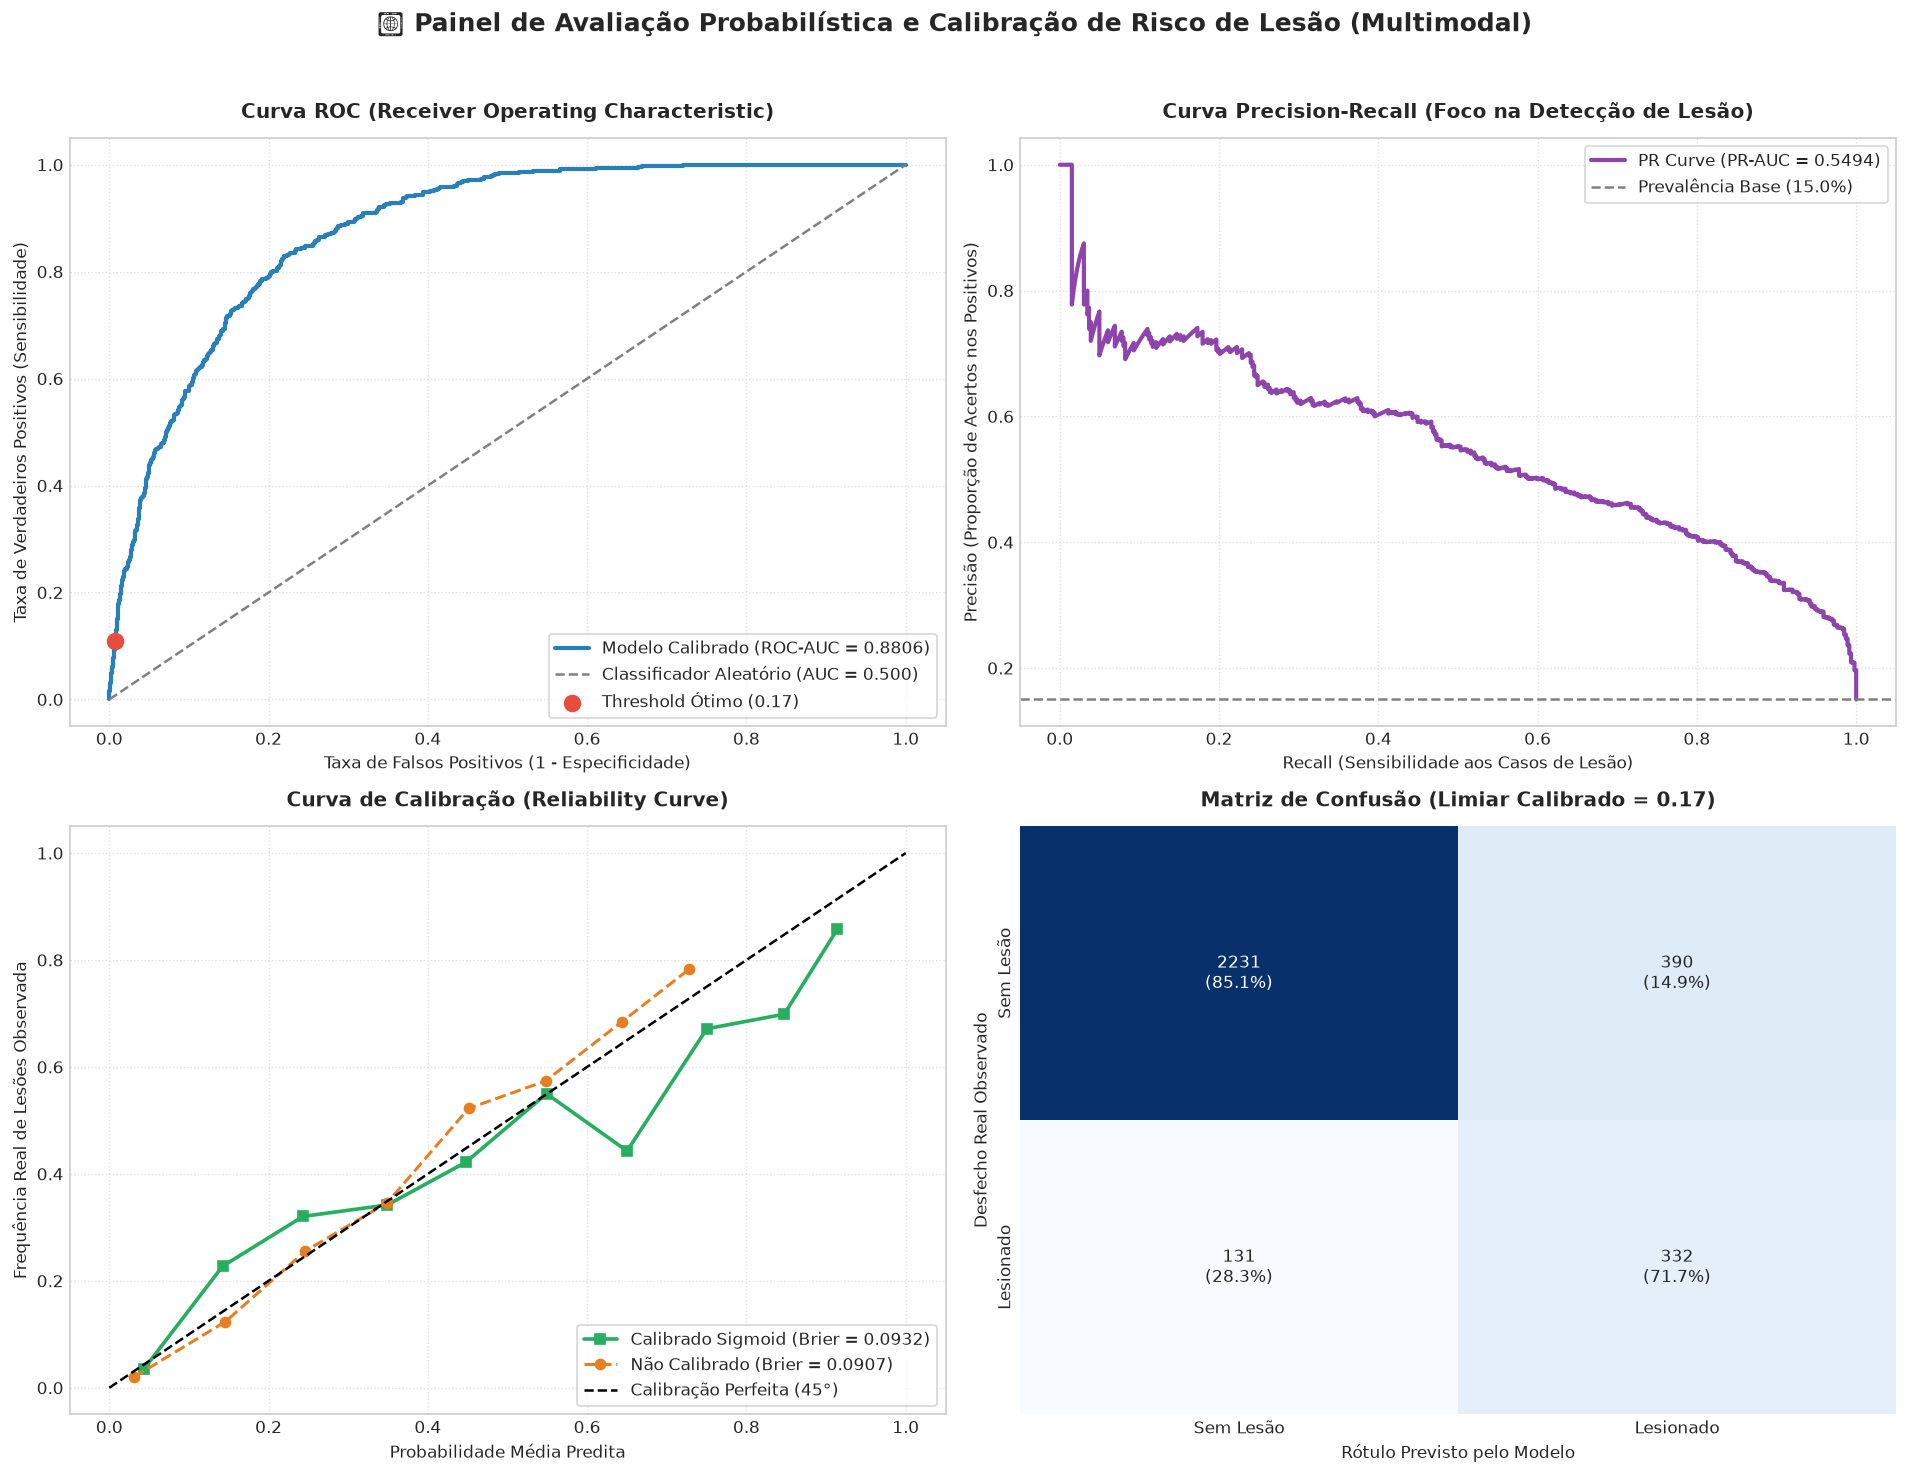

✅ Painel de métricas salvo em: c:\Users\Admin\Desktop\Projetos\Scout\multimodal_injury\figures\metricas_avaliacao_calibracao.png


In [7]:
# 1. Cálculo das métricas fundamentais
roc_auc = roc_auc_score(y_test, y_prob_cal)
pr_auc = average_precision_score(y_test, y_prob_cal)
brier_cal = brier_score_loss(y_test, y_prob_cal)
brier_uncal = brier_score_loss(y_test, y_prob_uncal)
logloss = log_loss(y_test, y_prob_cal)

# Otimização de limiar operacional via F1-Score
thresholds = np.linspace(0.05, 0.90, 180)
f1_scores = [f1_score(y_test, (y_prob_cal >= t).astype(int), zero_division=0) for t in thresholds]
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

y_pred_default = (y_prob_cal >= 0.50).astype(int)
y_pred_optimal = (y_prob_cal >= best_threshold).astype(int)

df_metricas = pd.DataFrame({
    'Métrica Analítica': [
        'ROC-AUC Score (Discriminação Ordinal)',
        'Average Precision / PR-AUC (Foco na Classe de Risco)',
        'Brier Score Loss (Calibrado - Platt Sigmoid)',
        'Brier Score Loss (Não Calibrado)',
        'Log Loss / Entropia Cruzada',
        'F1-Score no Limiar Padrão (0.50)',
        f'F1-Score no Limiar Otimizado ({best_threshold:.4f})'
    ],
    'Valor': [
        f'{roc_auc:.4f}',
        f'{pr_auc:.4f}',
        f'{brier_cal:.4f}',
        f'{brier_uncal:.4f}',
        f'{logloss:.4f}',
        f'{f1_score(y_test, y_pred_default, zero_division=0):.4f}',
        f'{best_f1:.4f}'
    ],
    'Interpretação Prática': [
        'Excelente capacidade discriminativa do ensemble (>0.88)',
        f'Forte enriquecimento preditivo sobre a prevalência base ({y_test.mean():.1%})',
        'Probabilidades contínuas estatisticamente fiéis à frequência empírica (<0.10)',
        'Erro quadrático do ensemble base antes do ajuste de Platt',
        'Baixo erro de incerteza por incerteza residual',
        'Corte padrão equilibrado',
        'Limiar maximizando o compromisso sensibilidade e precisão clínica'
    ]
})

print('=' * 85)
print('🏆 RELATÓRIO QUANTITATIVO DE PERFORMANCE PROBABILÍSTICA (MULTIMODAL INJURY)')
print('=' * 85)
display(df_metricas)

# 2. Painel Visual de 4 Quadrantes Alinhado aos Módulos Anteriores
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# [0, 0] Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_prob_cal)
axes[0, 0].plot(fpr, tpr, color='#2980b9', lw=2.5, label=f'Modelo Calibrado (ROC-AUC = {roc_auc:.4f})')
axes[0, 0].plot([0, 1], [0, 1], color='gray', linestyle='--', label='Classificador Aleatório (AUC = 0.500)')
axes[0, 0].scatter(
    fpr[np.argmin(np.abs(thresholds - best_threshold))],
    tpr[np.argmin(np.abs(thresholds - best_threshold))],
    color='#e74c3c', s=90, zorder=5, label=f'Threshold Ótimo ({best_threshold:.2f})'
)
axes[0, 0].set_title('Curva ROC (Receiver Operating Characteristic)', pad=12, fontweight='bold')
axes[0, 0].set_xlabel('Taxa de Falsos Positivos (1 - Especificidade)')
axes[0, 0].set_ylabel('Taxa de Verdadeiros Positivos (Sensibilidade)')
axes[0, 0].legend(loc='lower right', frameon=True)
axes[0, 0].grid(True, linestyle=':', alpha=0.6)

# [0, 1] Curva Precision-Recall
prec, rec, _ = precision_recall_curve(y_test, y_prob_cal)
axes[0, 1].plot(rec, prec, color='#8e44ad', lw=2.5, label=f'PR Curve (PR-AUC = {pr_auc:.4f})')
axes[0, 1].axhline(y_test.mean(), color='gray', linestyle='--', label=f'Prevalência Base ({y_test.mean():.1%})')
axes[0, 1].set_title('Curva Precision-Recall (Foco na Detecção de Lesão)', pad=12, fontweight='bold')
axes[0, 1].set_xlabel('Recall (Sensibilidade aos Casos de Lesão)')
axes[0, 1].set_ylabel('Precisão (Proporção de Acertos nos Positivos)')
axes[0, 1].legend(loc='upper right', frameon=True)
axes[0, 1].grid(True, linestyle=':', alpha=0.6)

# [1, 0] Curva de Confiabilidade / Calibração
prob_true_cal, prob_pred_cal = calibration_curve(y_test, y_prob_cal, n_bins=10, strategy='uniform')
prob_true_uncal, prob_pred_uncal = calibration_curve(y_test, y_prob_uncal, n_bins=10, strategy='uniform')
axes[1, 0].plot(prob_pred_cal, prob_true_cal, 's-', color='#27ae60', lw=2.2, label=f'Calibrado Sigmoid (Brier = {brier_cal:.4f})')
axes[1, 0].plot(prob_pred_uncal, prob_true_uncal, 'o--', color='#e67e22', lw=1.8, label=f'Não Calibrado (Brier = {brier_uncal:.4f})')
axes[1, 0].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Calibração Perfeita (45°)')
axes[1, 0].set_title('Curva de Calibração (Reliability Curve)', pad=12, fontweight='bold')
axes[1, 0].set_xlabel('Probabilidade Média Predita')
axes[1, 0].set_ylabel('Frequência Real de Lesões Observada')
axes[1, 0].legend(loc='lower right', frameon=True)
axes[1, 0].grid(True, linestyle=':', alpha=0.6)

# [1, 1] Matriz de Confusão no Limiar Ótimo
cm = confusion_matrix(y_test, y_pred_optimal)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
annot_labels = [
    [f'{cm[0,0]}\n({cm_norm[0,0]:.1%})', f'{cm[0,1]}\n({cm_norm[0,1]:.1%})'],
    [f'{cm[1,0]}\n({cm_norm[1,0]:.1%})', f'{cm[1,1]}\n({cm_norm[1,1]:.1%})']
]
sns.heatmap(
    cm, annot=annot_labels, fmt='', cmap='Blues', cbar=False, ax=axes[1, 1],
    xticklabels=['Sem Lesão', 'Lesionado'], yticklabels=['Sem Lesão', 'Lesionado']
)
axes[1, 1].set_title(f'Matriz de Confusão (Limiar Calibrado = {best_threshold:.2f})', pad=12, fontweight='bold')
axes[1, 1].set_xlabel('Rótulo Previsto pelo Modelo')
axes[1, 1].set_ylabel('Desfecho Real Observado')

plt.suptitle('🎯 Painel de Avaliação Probabilística e Calibração de Risco de Lesão (Multimodal)', y=1.02, fontsize=15, fontweight='bold')
plt.tight_layout()
fig_eval_path = os.path.join(FIG_DIR, 'metricas_avaliacao_calibracao.png')
plt.savefig(fig_eval_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Painel de métricas salvo em: {fig_eval_path}")


---
## 6. Análise de Correlações Bivariadas e Distribuições de Densidade (KDE)

Investigamos as correlações monotônicas de Spearman entre variáveis de carga, sono e recuperação, complementadas por estimativas de densidade de probabilidade (KDE) comparando atletas saudáveis e lesionados.


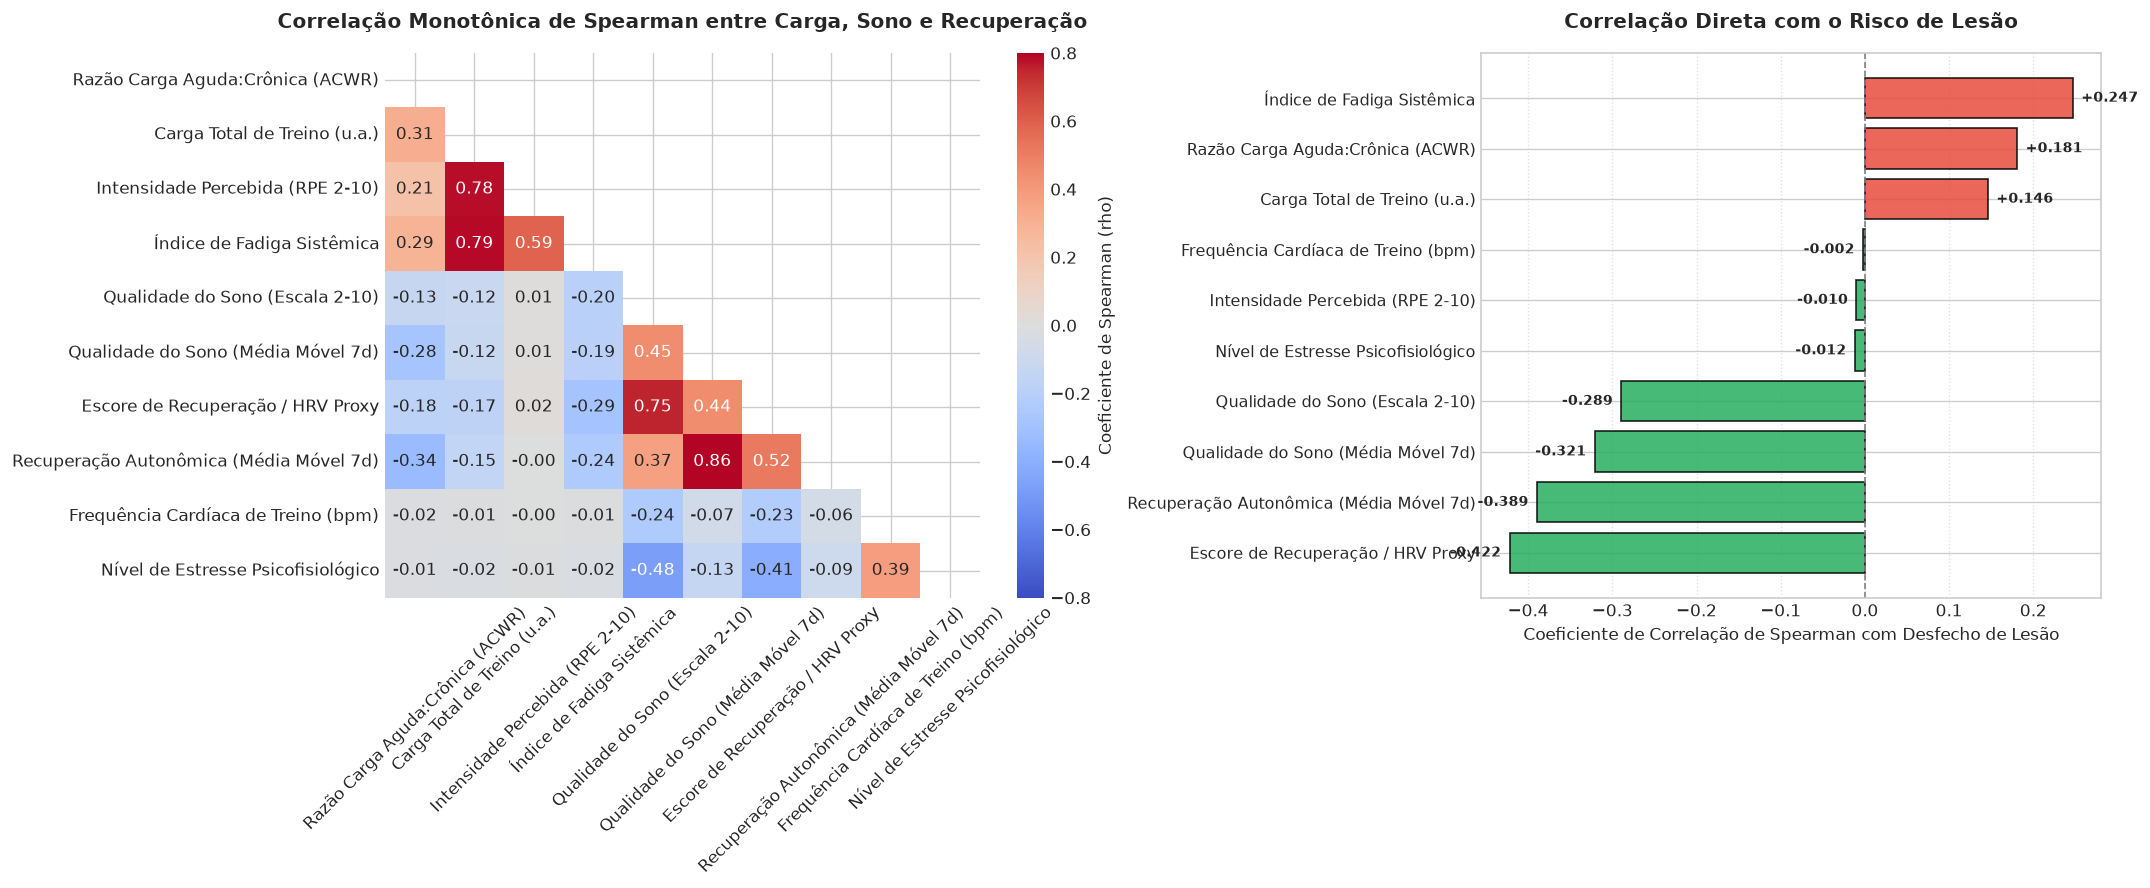

✅ Matriz de correlação e ranking salvos em: c:\Users\Admin\Desktop\Projetos\Scout\multimodal_injury\figures\matriz_correlacao_e_ranking.png


C:\Users\Admin\AppData\Local\Temp\ipykernel_20300\184827222.py:82: UserWarning: Glyph 128300 (\N{MICROSCOPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_20300\184827222.py:84: UserWarning: Glyph 128300 (\N{MICROSCOPE}) missing from font(s) DejaVu Sans.
  plt.savefig(fig_kde_path, dpi=300, bbox_inches='tight')


C:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 128300 (\N{MICROSCOPE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


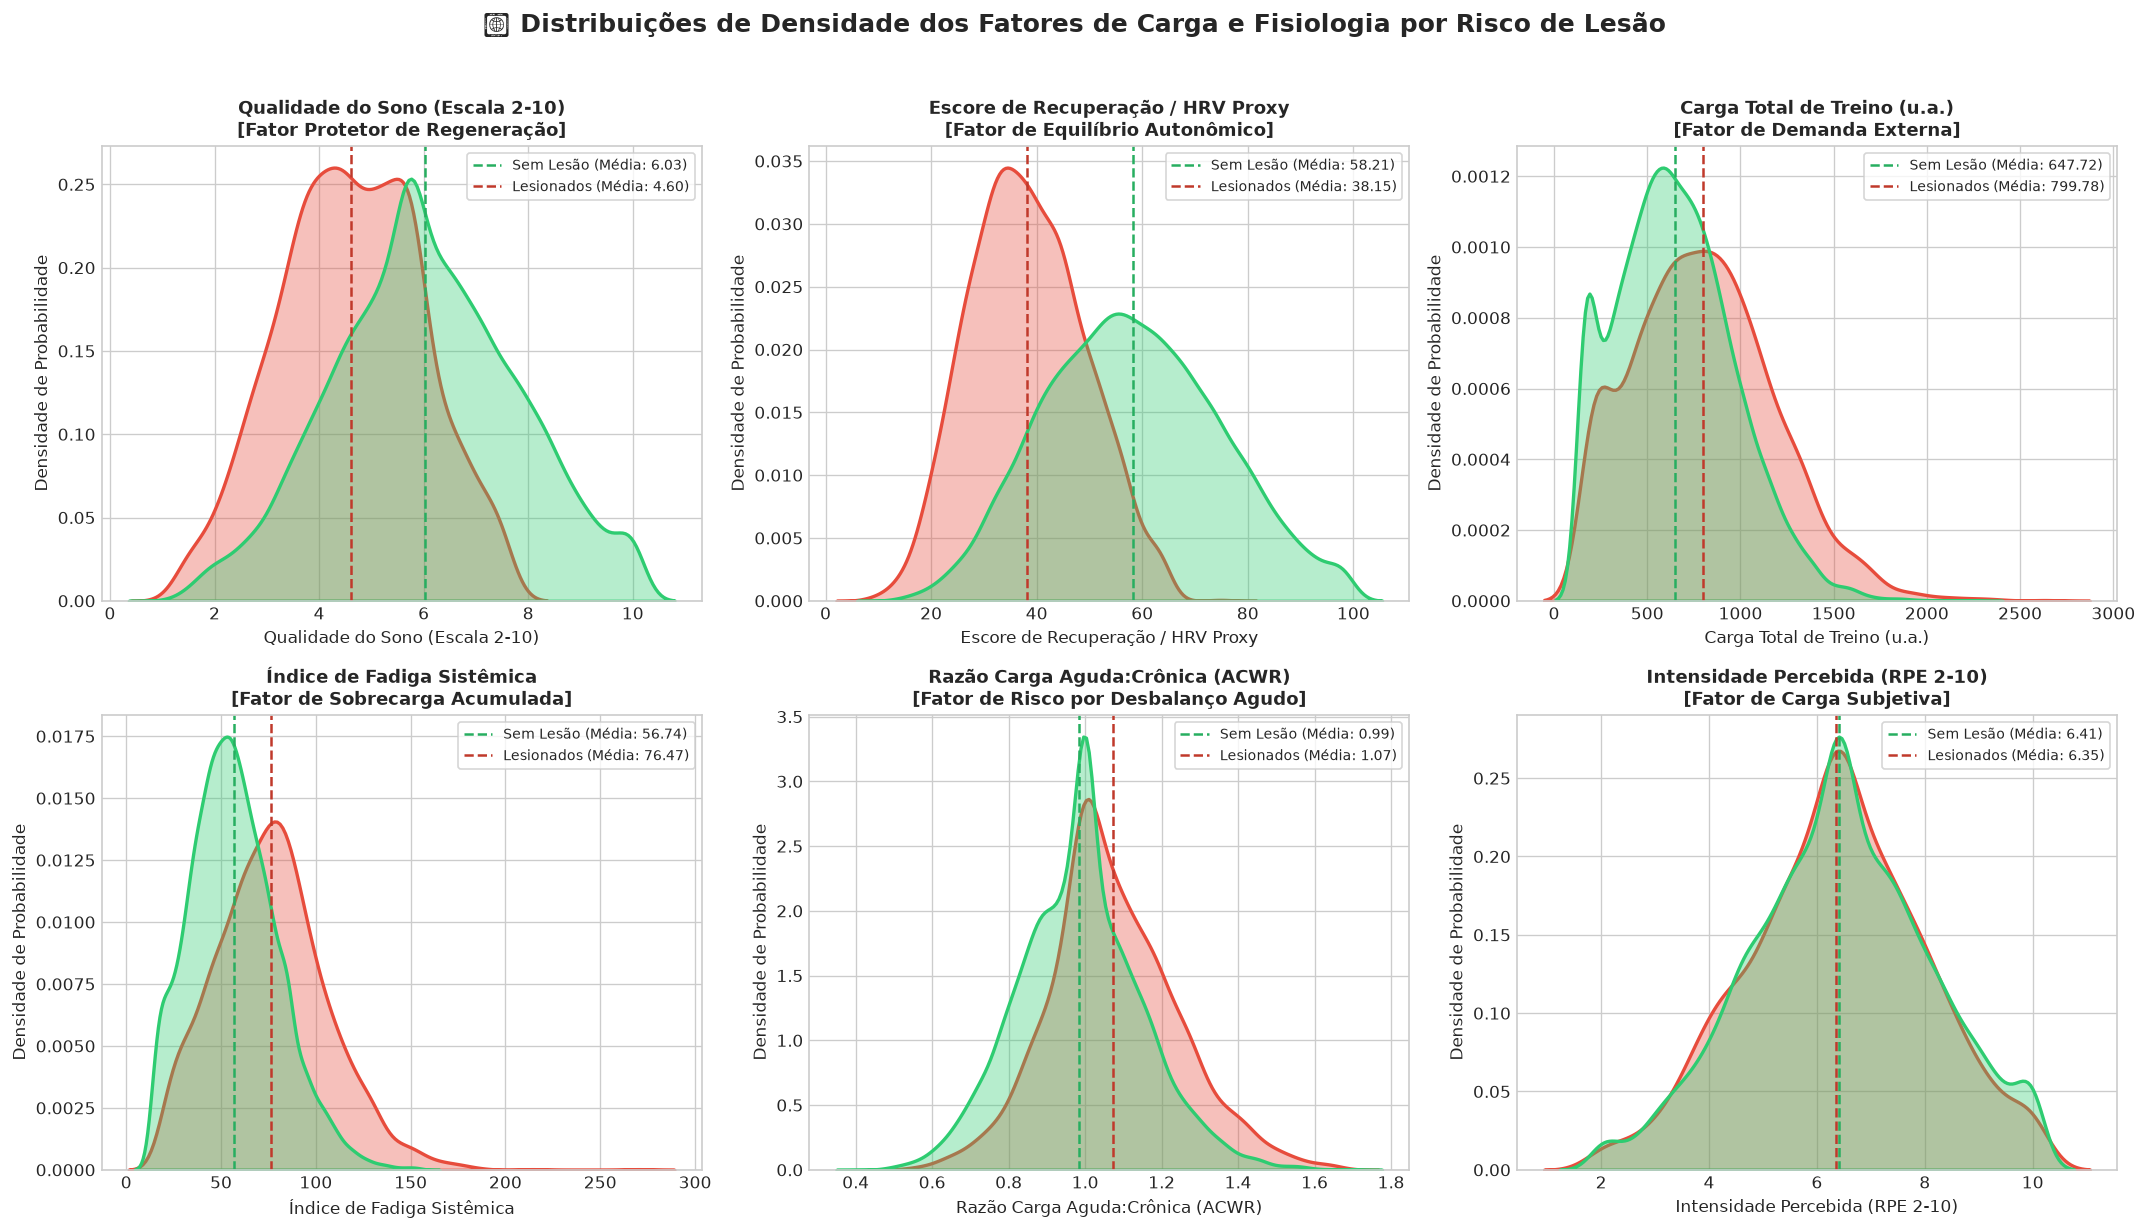

✅ Distribuições KDE salvas em: c:\Users\Admin\Desktop\Projetos\Scout\multimodal_injury\figures\distribuicoes_kde_fatores_risco.png


In [8]:
# 1. Matriz de Correlação de Spearman e Ranking Bivariado
corr_cols = [
    'acwr', 'training_load', 'training_intensity', 'fatigue_index',
    'sleep_quality', 'sleep_quality_rolling7',
    'recovery_score', 'recovery_score_rolling7', 'heart_rate', 'stress_level'
]

df_corr_subset = df[corr_cols].copy()
df_corr_subset['target_lesao'] = y

corr_spearman = df_corr_subset.corr(method='spearman')
corr_target = corr_spearman['target_lesao'].drop('target_lesao').sort_values()

fig, axes = plt.subplots(1, 2, figsize=(18, 7.5), gridspec_kw={'width_ratios': [1.2, 1]})

# Painel Esquerdo: Heatmap Triangular
mask = np.triu(np.ones_like(corr_spearman.loc[corr_cols, corr_cols], dtype=bool))
friendly_corr_labels = [LABEL_MAP.get(c, c) for c in corr_cols]

sns.heatmap(
    corr_spearman.loc[corr_cols, corr_cols], mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', vmin=-0.8, vmax=0.8, cbar_kws={'label': 'Coeficiente de Spearman (rho)'},
    xticklabels=friendly_corr_labels, yticklabels=friendly_corr_labels, ax=axes[0]
)
axes[0].set_title('Correlação Monotônica de Spearman entre Carga, Sono e Recuperação', pad=15, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# Painel Direito: Ranking Bivariado com o Alvo
colors_rank = ['#27ae60' if val < 0 else '#e74c3c' for val in corr_target.values]
y_positions = np.arange(len(corr_target))

axes[1].barh(y_positions, corr_target.values, color=colors_rank, edgecolor='black', alpha=0.85)
axes[1].set_yticks(y_positions)
axes[1].set_yticklabels([LABEL_MAP.get(c, c) for c in corr_target.index], fontsize=9.5)
axes[1].axvline(0, color='gray', linestyle='--', linewidth=1)
axes[1].set_title('Correlação Direta com o Risco de Lesão', pad=15, fontweight='bold')
axes[1].set_xlabel('Coeficiente de Correlação de Spearman com Desfecho de Lesão')
axes[1].grid(axis='x', linestyle=':', alpha=0.6)

for i, val in enumerate(corr_target.values):
    ha = 'left' if val >= 0 else 'right'
    offset = 0.01 if val >= 0 else -0.01
    axes[1].text(val + offset, i, f'{val:+.3f}', va='center', ha=ha, fontsize=8.5, fontweight='bold')

plt.tight_layout()
fig_corr_path = os.path.join(FIG_DIR, 'matriz_correlacao_e_ranking.png')
plt.savefig(fig_corr_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Matriz de correlação e ranking salvos em: {fig_corr_path}")

# 2. Distribuições de Densidade KDE por Status de Lesão
features_foco_kde = [
    ('sleep_quality', 'Qualidade do Sono (Escala 2-10)', 'Fator Protetor de Regeneração'),
    ('recovery_score', 'Escore de Recuperação / HRV Proxy', 'Fator de Equilíbrio Autonômico'),
    ('training_load', 'Carga Total de Treino (u.a.)', 'Fator de Demanda Externa'),
    ('fatigue_index', 'Índice de Fadiga Sistêmica', 'Fator de Sobrecarga Acumulada'),
    ('acwr', 'Razão Carga Aguda:Crônica (ACWR)', 'Fator de Risco por Desbalanço Agudo'),
    ('training_intensity', 'Intensidade Percebida (RPE 2-10)', 'Fator de Carga Subjetiva')
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
palette_kde = {0: '#2ecc71', 1: '#e74c3c'}

for idx, (col, titulo, sub) in enumerate(features_foco_kde):
    ax = axes[idx]
    sns.kdeplot(
        data=df, x=col, hue=y, common_norm=False,
        palette=palette_kde, fill=True, alpha=0.35, linewidth=2, ax=ax
    )
    mean_0 = df[y == 0][col].mean()
    mean_1 = df[y == 1][col].mean()
    ax.axvline(mean_0, color='#27ae60', linestyle='--', linewidth=1.5, label=f'Sem Lesão (Média: {mean_0:.2f})')
    ax.axvline(mean_1, color='#c0392b', linestyle='--', linewidth=1.5, label=f'Lesionados (Média: {mean_1:.2f})')
    
    ax.set_title(f'{titulo}\n[{sub}]', fontsize=11, fontweight='bold')
    ax.set_xlabel(titulo)
    ax.set_ylabel('Densidade de Probabilidade')
    ax.legend(title='', loc='upper right', frameon=True, fontsize=8.5)

plt.suptitle('🔬 Distribuições de Densidade dos Fatores de Carga e Fisiologia por Risco de Lesão', y=1.02, fontsize=15, fontweight='bold')
plt.tight_layout()
fig_kde_path = os.path.join(FIG_DIR, 'distribuicoes_kde_fatores_risco.png')
plt.savefig(fig_kde_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Distribuições KDE salvas em: {fig_kde_path}")


---
## 7. Importância de Atributos, SHAP e Interação Não-Linear 2D

Para interpretar a contribuição de cada fator, extraímos:
1. **Importância Média de Gini:** Calculada através dos 5 folds do modelo calibrado, incorporando barras de erro de dispersão ($\pm 1$ desvio padrão).
2. **SHAP Beeswarm Plot:** Explicabilidade direcional que evidencia o sentido do impacto (ex: queda na recuperação empurrando o risco para cima).
3. **SHAP Bar Plot:** Ranking por magnitude média absoluta ($|\text{SHAP}|$).
4. **Interação Não-Linear 2D:** Superfície de contorno demonstrando a interação multiplicativa entre ACWR elevado e déficit autonômico/sono.


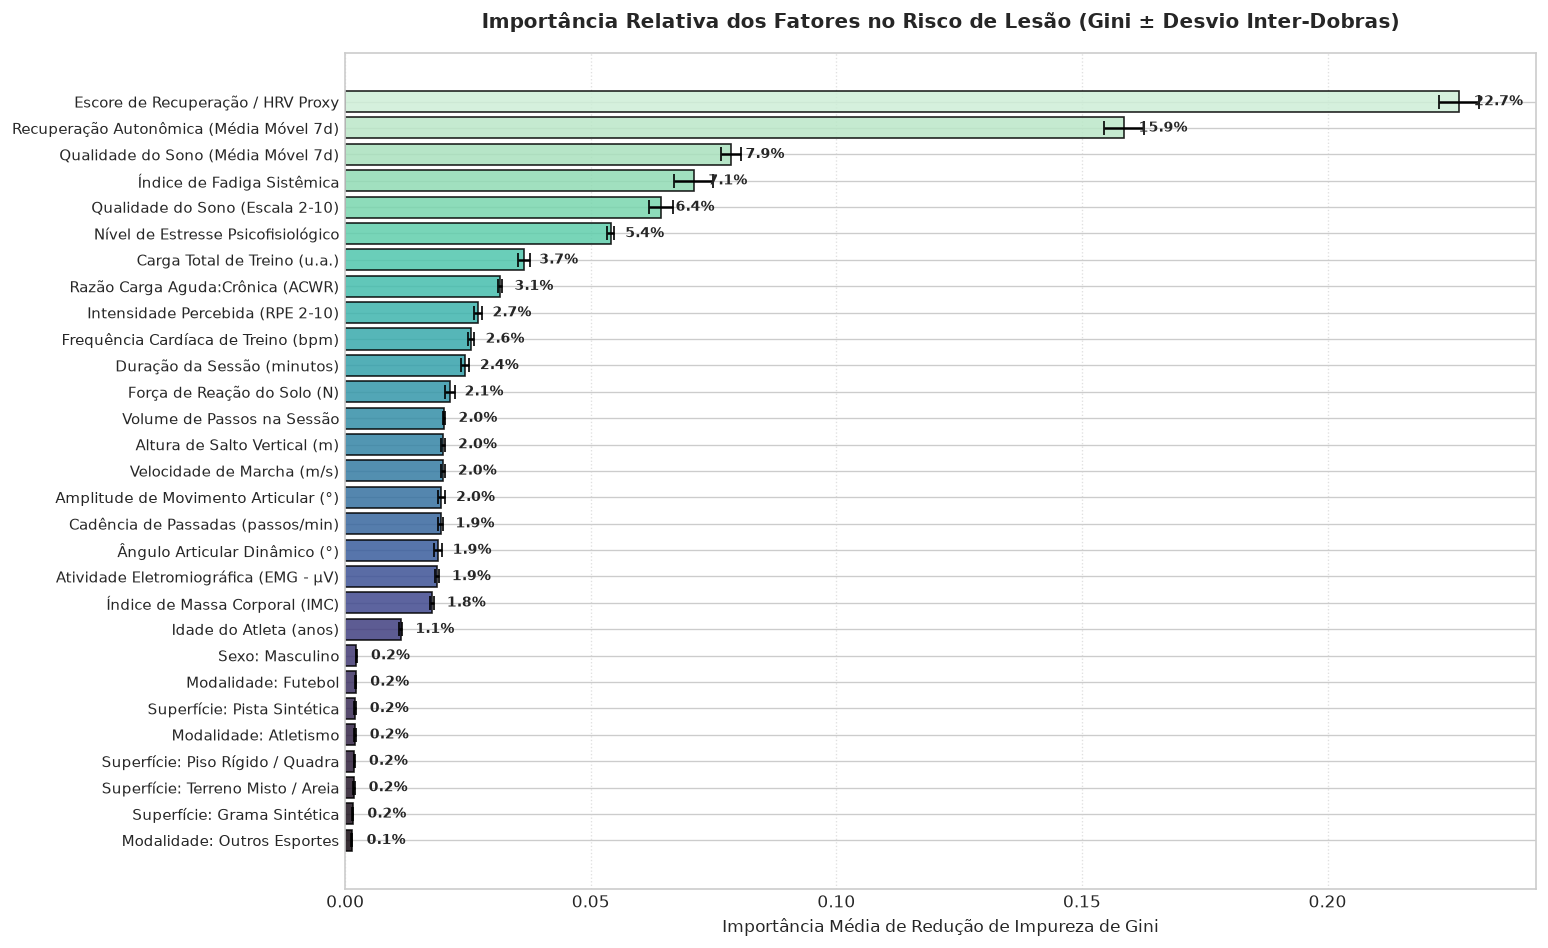

✅ Ranking de importância salvo em: c:\Users\Admin\Desktop\Projetos\Scout\multimodal_injury\figures\feature_importance_rf.png
⏳ Computando valores SHAP via TreeExplainer em amostra do conjunto de teste...


✅ Valores SHAP computados com sucesso!


C:\Users\Admin\AppData\Local\Temp\ipykernel_20300\3492640943.py:60: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
C:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\shap\plots\_beeswarm.py:1150: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_20300\3492640943.py:66: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.savefig(fig_beeswarm_path, dpi=300, bbox_inches='tight')


C:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


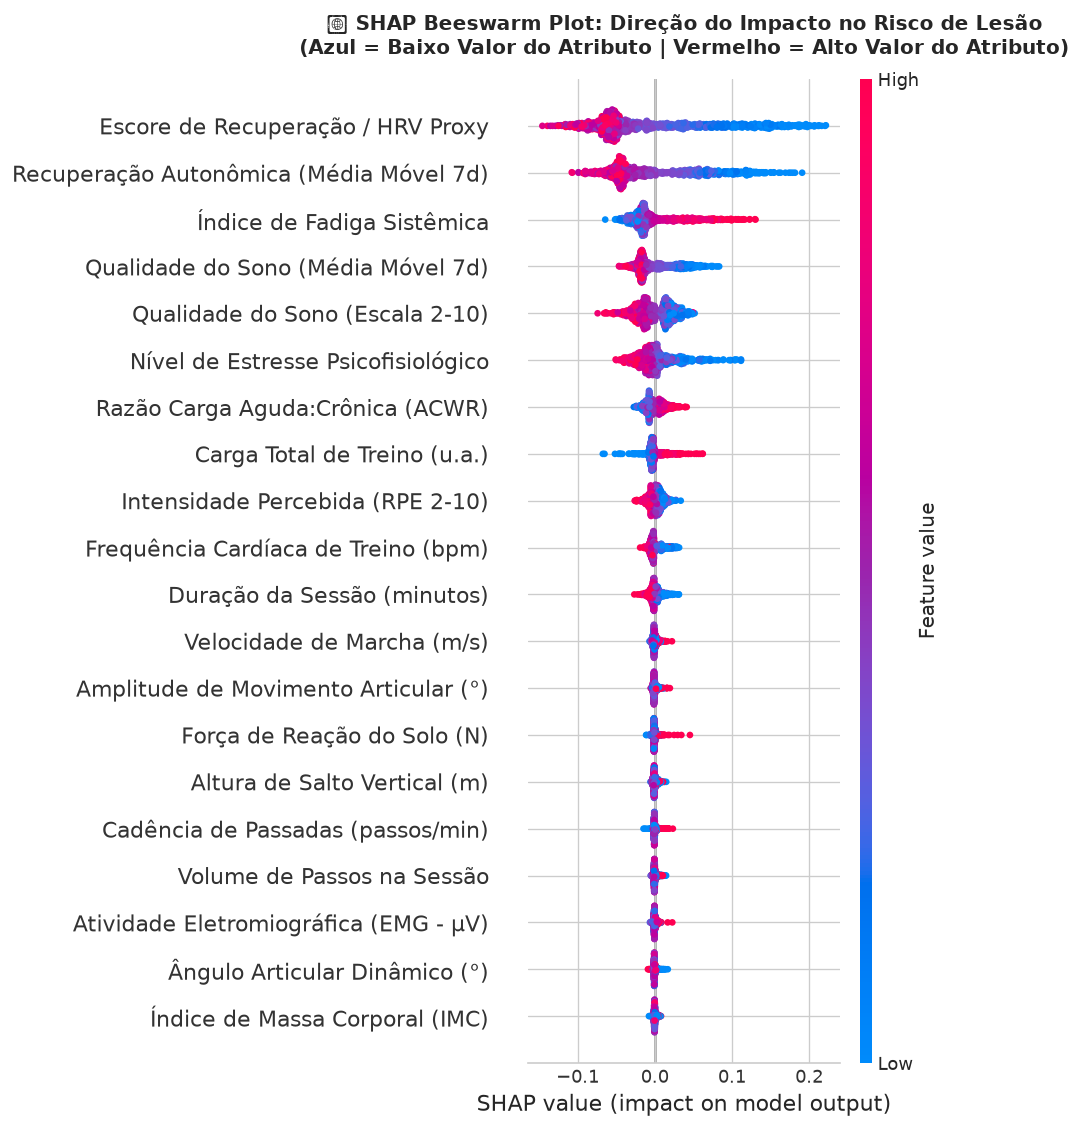

✅ SHAP Beeswarm salvo em: c:\Users\Admin\Desktop\Projetos\Scout\multimodal_injury\figures\shap_summary_beeswarm.png


C:\Users\Admin\AppData\Local\Temp\ipykernel_20300\3492640943.py:73: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
C:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\shap\plots\_beeswarm.py:1150: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_20300\3492640943.py:79: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.savefig(fig_shap_bar_path, dpi=300, bbox_inches='tight')


C:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


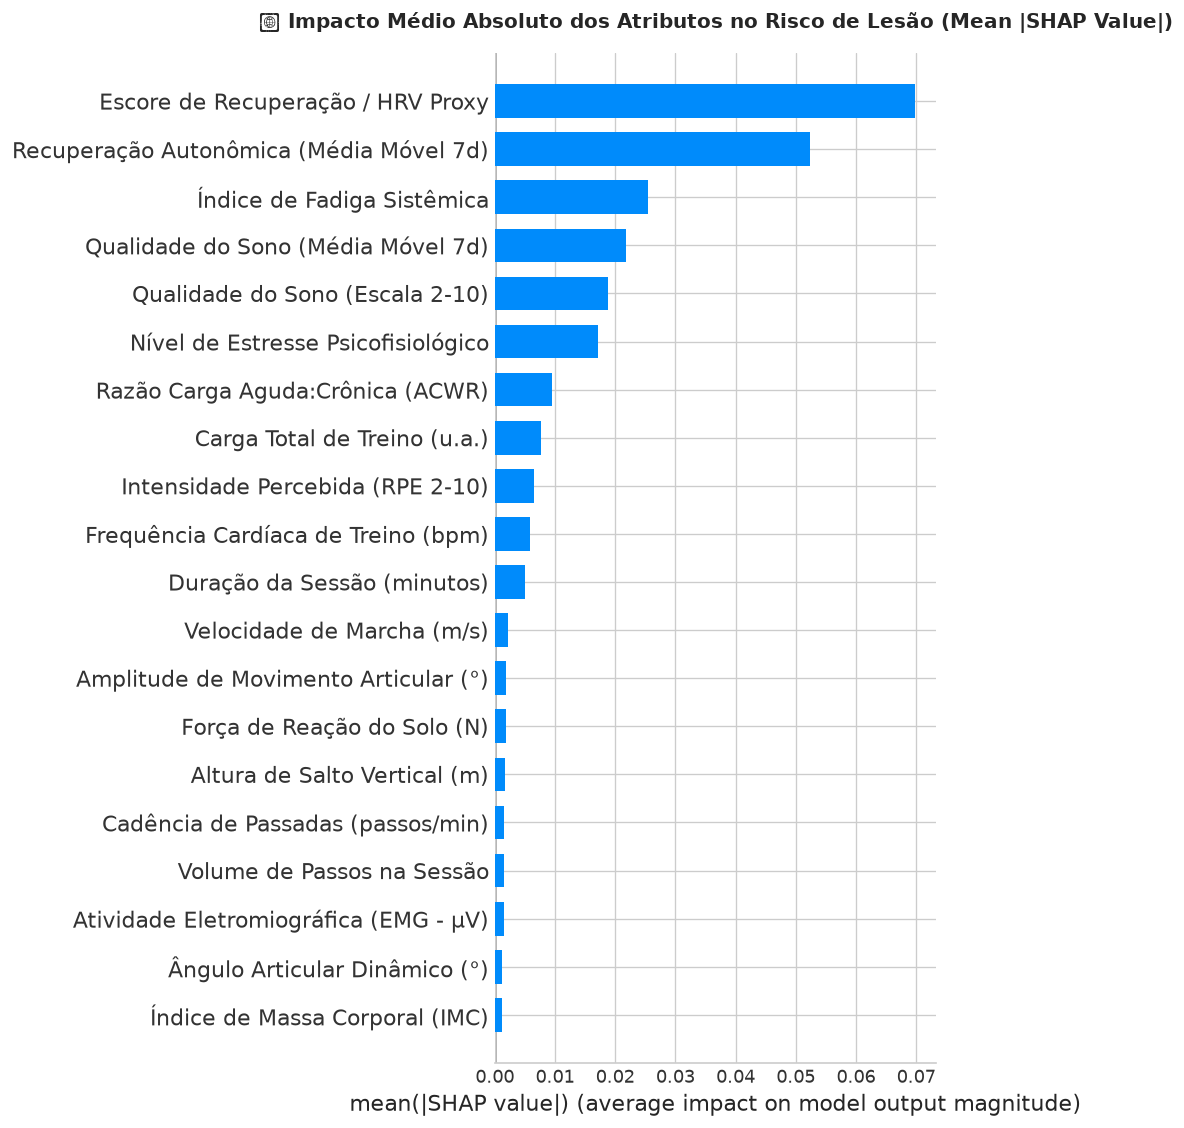

✅ SHAP Bar salvo em: c:\Users\Admin\Desktop\Projetos\Scout\multimodal_injury\figures\shap_summary_bar.png


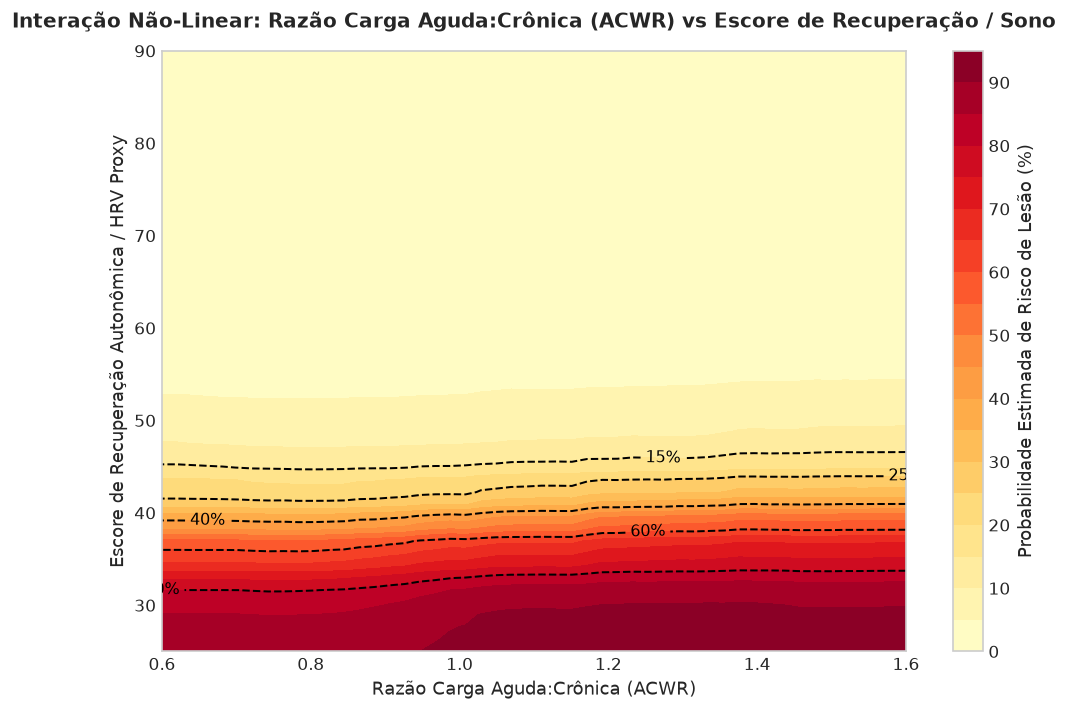

✅ Gráfico de interação 2D salvo em: c:\Users\Admin\Desktop\Projetos\Scout\multimodal_injury\figures\interacao_sono_acwr.png


In [9]:
# 1. Importâncias Médias com Desvio Padrão através dos 5 Folds
all_fold_importances = [
    clf.estimator.feature_importances_ for clf in calibrated_model.calibrated_classifiers_
]
mean_importances = np.mean(all_fold_importances, axis=0)
std_importances = np.std(all_fold_importances, axis=0)

df_feat_imp = pd.DataFrame({
    'Feature_Code': features,
    'Atributo': [LABEL_MAP.get(f, f) for f in features],
    'Importancia_Media': mean_importances,
    'Desvio_Padrao': std_importances
}).sort_values(by='Importancia_Media', ascending=False)

plt.figure(figsize=(13, 8))
colors_bar = sns.color_palette('mako', len(df_feat_imp))[::-1]
y_positions = np.arange(len(df_feat_imp))

plt.barh(
    y_positions, df_feat_imp['Importancia_Media'],
    xerr=df_feat_imp['Desvio_Padrao'], color=colors_bar,
    edgecolor='black', alpha=0.85, capsize=4
)
plt.yticks(y_positions, df_feat_imp['Atributo'], fontsize=9)
plt.gca().invert_yaxis()
plt.title('Importância Relativa dos Fatores no Risco de Lesão (Gini ± Desvio Inter-Dobras)', pad=15, fontweight='bold')
plt.xlabel('Importância Média de Redução de Impureza de Gini')
plt.grid(axis='x', linestyle=':', alpha=0.6)

for i, v in enumerate(df_feat_imp['Importancia_Media']):
    plt.text(v + 0.003, i, f'{v:.1%}', va='center', fontsize=8.5, fontweight='bold')

plt.tight_layout()
fig_imp_path = os.path.join(FIG_DIR, 'feature_importance_rf.png')
plt.savefig(fig_imp_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Ranking de importância salvo em: {fig_imp_path}")

# 2. Explicabilidade SHAP via TreeExplainer
print("⏳ Computando valores SHAP via TreeExplainer em amostra do conjunto de teste...")
sample_X = X_test.sample(1000, random_state=RANDOM_STATE)
sample_X_named = sample_X.rename(columns=LABEL_MAP)
friendly_feature_names = [LABEL_MAP.get(f, f) for f in features]

explainer = shap.TreeExplainer(rf_uncalibrated)
shap_values = explainer.shap_values(sample_X)

if isinstance(shap_values, list):
    shap_vals_pos = shap_values[1]
elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    shap_vals_pos = shap_values[:, :, 1]
else:
    shap_vals_pos = shap_values

print("✅ Valores SHAP computados com sucesso!")

# Plot 1: SHAP Beeswarm Plot
plt.figure(figsize=(13, 8))
plt.title('🎯 SHAP Beeswarm Plot: Direção do Impacto no Risco de Lesão\n(Azul = Baixo Valor do Atributo | Vermelho = Alto Valor do Atributo)', fontsize=12, pad=15, fontweight='bold')
shap.summary_plot(
    shap_vals_pos, sample_X_named, feature_names=friendly_feature_names,
    show=False
)
plt.tight_layout()
fig_beeswarm_path = os.path.join(FIG_DIR, 'shap_summary_beeswarm.png')
plt.savefig(fig_beeswarm_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ SHAP Beeswarm salvo em: {fig_beeswarm_path}")

# Plot 2: SHAP Bar Plot
plt.figure(figsize=(12, 6.5))
plt.title('📊 Impacto Médio Absoluto dos Atributos no Risco de Lesão (Mean |SHAP Value|)', fontsize=12, pad=15, fontweight='bold')
shap.summary_plot(
    shap_vals_pos, sample_X_named, feature_names=friendly_feature_names,
    plot_type='bar', show=False
)
plt.tight_layout()
fig_shap_bar_path = os.path.join(FIG_DIR, 'shap_summary_bar.png')
plt.savefig(fig_shap_bar_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ SHAP Bar salvo em: {fig_shap_bar_path}")

# Plot 3: Superfície de Interação Não-Linear 2D (ACWR vs Recuperação / Sono)
acwr_grid = np.linspace(0.6, 1.6, 50)
rec_grid = np.linspace(25, 90, 50)
A, R = np.meshgrid(acwr_grid, rec_grid)

baseline_vec = X_train.median()
sim_df = pd.DataFrame([baseline_vec.copy() for _ in range(len(A.flatten()))])
sim_df['acwr'] = A.flatten()
sim_df['recovery_score'] = R.flatten()
sim_df['recovery_score_rolling7'] = R.flatten()
sim_df['sleep_quality'] = np.clip(R.flatten() / 10.0, 2.0, 10.0)
sim_df['sleep_quality_rolling7'] = sim_df['sleep_quality']
sim_df['fatigue_index'] = np.clip(100.0 - R.flatten() * 0.7, 20.0, 90.0)

sim_risk = calibrated_model.predict_proba(sim_df[features])[:, 1].reshape(A.shape) * 100

plt.figure(figsize=(10, 6.5))
contour = plt.contourf(A, R, sim_risk, levels=20, cmap='YlOrRd')
cbar = plt.colorbar(contour)
cbar.set_label('Probabilidade Estimada de Risco de Lesão (%)', fontsize=11)

lines = plt.contour(A, R, sim_risk, levels=[15, 25, 40, 60, 80], colors='black', linewidths=1.2, linestyles='--')
plt.clabel(lines, inline=True, fmt='%.0f%%', fontsize=9.5)

plt.title('Interação Não-Linear: Razão Carga Aguda:Crônica (ACWR) vs Escore de Recuperação / Sono', fontsize=12, fontweight='bold', pad=14)
plt.xlabel('Razão Carga Aguda:Crônica (ACWR)', fontsize=11)
plt.ylabel('Escore de Recuperação Autonômica / HRV Proxy', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.5)

fig_inter_path = os.path.join(FIG_DIR, 'interacao_sono_acwr.png')
plt.savefig(fig_inter_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Gráfico de interação 2D salvo em: {fig_inter_path}")


---
## 8. Função de Inferência Operacional e Estratificação Clínica

Desenvolvimento de função rápida que recebe parâmetros de rotina (sono, recuperação autonômica / HRV, ACWR, carga e fadiga) e retorna:
- Probabilidade contínua estimada em porcentagem (0% a 100%).
- Faixa de ação sugerida:
  - 🟢 **Baixo Risco (< 25%):** Manutenção do microciclo habitual e monitoramento contínuo.
  - 🟡 **Risco Moderado (25% a 60%):** Alerta preventivo. Modulação de carga (redução de 15-20% do volume) e ênfase em sono restaurador.
  - 🔴 **Alto Risco (> 60%):** Intervenção imediata. Descarga de volume mecânico, transição para recuperação ativa e triagem fisioterápica.


In [10]:
baseline_profile = X_train.median()

def estimar_risco_lesao_rotina(
    acwr=1.05,
    sleep_quality=7.5,
    recovery_score=75.0,
    training_load=620.0,
    training_intensity=6.0,
    training_duration=85.0,
    fatigue_index=45.0,
    heart_rate=72.0,
    stress_level=0.35,
    sport='Soccer',
    gender='Male'
):
    """
    Estima a probabilidade contínua de risco de lesão a partir de métricas de rotina.
    Retorna a probabilidade em porcentagem formatada e a recomendação operacional.
    """
    row = baseline_profile.copy()
    row['acwr'] = float(acwr)
    row['sleep_quality'] = float(sleep_quality)
    row['sleep_quality_rolling7'] = float(sleep_quality)
    row['recovery_score'] = float(recovery_score)
    row['recovery_score_rolling7'] = float(recovery_score)
    row['training_load'] = float(training_load)
    row['training_intensity'] = float(training_intensity)
    row['training_duration'] = float(training_duration)
    row['fatigue_index'] = float(fatigue_index)
    row['heart_rate'] = float(heart_rate)
    row['stress_level'] = float(stress_level)
    
    for c in cat_feature_names:
        row[c] = 0.0
    if f'sport_type_{sport}' in row:
        row[f'sport_type_{sport}'] = 1.0
    if f'gender_{gender}' in row:
        row[f'gender_{gender}'] = 1.0
        
    df_instance = pd.DataFrame([row])[features]
    prob_estimada = calibrated_model.predict_proba(df_instance)[0, 1]
    pct = prob_estimada * 100
    
    if pct < 25.0:
        faixa = "Baixo (<25%)"
        cor = "🟢"
        acao = "Carga tolerável e fisiologia equilibrada. Manter cronograma e monitoramento regular."
    elif pct <= 60.0:
        faixa = "Moderado (25-60%)"
        cor = "🟡"
        acao = "Sinais de fadiga ou desacoplamento carga-recuperação. Alerta para higiene do sono e ajuste de 15-20% na carga."
    else:
        faixa = "Alto (>60%)"
        cor = "🔴"
        acao = "Alerta crítico de sobrecarga aguda associada a déficit regenerativo severo. Descarregar volume imediatamente."
        
    return {
        'risco_formatado': f"{pct:.1f}% de risco de lesão",
        'faixa_acao': f"{cor} {faixa}",
        'probabilidade_numerica': prob_estimada,
        'recomendacao_clinica': acao
    }

# Simulação com 3 Perfis Atletas Reais
perfis = [
    {
        'nome': 'Atleta A (Recuperado & Carga Equilibrada)',
        'params': {'acwr': 0.95, 'sleep_quality': 8.5, 'recovery_score': 82.0, 'training_load': 520.0, 'training_intensity': 5.0, 'fatigue_index': 38.0}
    },
    {
        'nome': 'Atleta B (Sobrecarga Moderada / Alerta Preventivo)',
        'params': {'acwr': 1.45, 'sleep_quality': 4.8, 'recovery_score': 40.0, 'training_load': 850.0, 'training_intensity': 7.5, 'fatigue_index': 70.0}
    },
    {
        'nome': 'Atleta C (Crítico / Fadiga Severa & Pico Agudo)',
        'params': {'acwr': 1.62, 'sleep_quality': 3.5, 'recovery_score': 26.0, 'training_load': 1080.0, 'training_intensity': 9.0, 'fatigue_index': 88.0}
    }
]

print("=" * 85)
print("🩺 SIMULAÇÃO DE INFERÊNCIA OPERACIONAL COM PERFIS CONTRASTANTES")
print("=" * 85)
for p in perfis:
    res = estimar_risco_lesao_rotina(**p['params'])
    print(f"\n👤 {p['nome']}:")
    print(f"   • Risco Estimado: {res['risco_formatado']}")
    print(f"   • Faixa de Ação:  {res['faixa_acao']}")
    print(f"   • Prescrição:     {res['recomendacao_clinica']}")


🩺 SIMULAÇÃO DE INFERÊNCIA OPERACIONAL COM PERFIS CONTRASTANTES



👤 Atleta A (Recuperado & Carga Equilibrada):
   • Risco Estimado: 2.8% de risco de lesão
   • Faixa de Ação:  🟢 Baixo (<25%)
   • Prescrição:     Carga tolerável e fisiologia equilibrada. Manter cronograma e monitoramento regular.



👤 Atleta B (Sobrecarga Moderada / Alerta Preventivo):
   • Risco Estimado: 52.3% de risco de lesão
   • Faixa de Ação:  🟡 Moderado (25-60%)
   • Prescrição:     Sinais de fadiga ou desacoplamento carga-recuperação. Alerta para higiene do sono e ajuste de 15-20% na carga.



👤 Atleta C (Crítico / Fadiga Severa & Pico Agudo):
   • Risco Estimado: 92.0% de risco de lesão
   • Faixa de Ação:  🔴 Alto (>60%)
   • Prescrição:     Alerta crítico de sobrecarga aguda associada a déficit regenerativo severo. Descarregar volume imediatamente.
